In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline

# Problem Set 1



### Linear Classifiers

- $(a)$

The cost function is:

$$
J(\theta) = \frac{-1}{m} \sum_{i=1}^{m} \Big( y^{(i)} \log(h_{\theta}(x^{(i)})) + (1 - y^{(i)}) \log(1-h_{\theta}(x^{(i)})) \Big)
$$

Then the gradient is:

$$
\nabla_{\mathbf{\theta}} J(\theta) = \frac{1}{m} \mathbf{X}^T (h_{\theta} - \mathbf{Y})
$$

the hessien is:
$$
H = \frac{\partial^2 J(\theta)}{\partial \theta \, \partial \theta^T} = X^T R X, \quad
R = \text{diag}\Big(h_\theta(x^{(i)}) \big( 1 - h_\theta(x^{(i)}) \big)\Big)
$$

Then the Newton-Raphson update for logistic regression is:

$$
\displaystyle
\theta^{(t+1)} = \theta^{(t)} - H^{-1} \nabla J(\theta^{(t)})
$$

In [2]:
df_train = pd.read_csv(r"C:\Users\USER\Documents\ml\cs229-2018-autumn\problem-sets\PS1\data\ds1_train.csv")
df_test = pd.read_csv(r"C:\Users\USER\Documents\ml\cs229-2018-autumn\problem-sets\PS1\data\ds1_valid.csv")
df_train.head()
df_test.head()

,x_1,x_2,y
0,2.177396,78.630076,0.0
1,3.952131,123.541573,0.0
2,3.351176,47.752517,0.0
3,2.074934,26.997730,0.0
4,3.579775,226.703779,0.0


In [ ]:
# class LogisticRegression():

#     def __init__(self):
#         self.theta = None

#     def add_intercept(self, X):
#         new_X = np.zeros((X.shape[0], X.shape[1] + 1), dtype=X.dtype)
#         new_X[:,0] = 1
#         new_X[:,1:] = X
#         return new_X

#     def fit(self, X, y, add_intercept=True):

#         if add_intercept:
#             X = self.add_intercept(X)

#         y = y.reshape(-1,1)

#         m, n = X.shape
#         self.theta = np.zeros((n,1))

#         grad = np.ones((n,1))
#         eps = 1e-5
#         max_iter = 100

#         for _ in range(max_iter):

#             hyp = 1/(1 + np.exp(-X @ self.theta))

#             grad = (1/m) * X.T @ (hyp - y)

#             R = hyp * (1 - hyp)

#             H = (1/m) * X.T @ (R * X)

#             self.theta -= np.linalg.solve(H, grad)

#             if np.linalg.norm(grad) < eps:
#                 break

#     def predict_prob(self, X, add_intercept=True):
#         if self.theta is None:
#             raise Exception("Model not trained yet")
        
#         if add_intercept:
#             X = self.add_intercept(X)
        
#         return 1/(1 + np.exp(-X @ self.theta))

#     def predict(self, X, add_intercept=True):

#         probs = self.predict_prob(X, add_intercept)

#         return (probs >= 0.5).astype(int)
    
#     def visualize(self, X, y):
#         pass       

In [3]:
X_train = df_train.drop('y', axis=1).to_numpy()
y_train = df_train[['y']].to_numpy().flatten()

X_test  = df_test.drop('y', axis=1).to_numpy()
y_test = df_test[['y']].to_numpy()



In [5]:
def visualize(model, X, y):
    # Create mesh grid
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                           np.linspace(x2_min, x2_max, 300))

    grid = np.c_[xx1.ravel(), xx2.ravel()]

    # Predict probabilities for every grid point
    Z = model.predict_prob(grid).reshape(xx1.shape)

    fig, ax = plt.subplots(figsize=(8, 8))

    # Colored background regions
    ax.contourf(xx1, xx2, Z, levels=1, cmap='RdYlBu_r', alpha=0.6)

    # Sharp decision boundary line at 0.5
    ax.contour(xx1, xx2, Z, levels=[0.5], colors='black', linewidths=2)

    # Scatter plot points
    ax.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1],
               c='blue', marker='o', s=60, label='Class 0', zorder=3)
    ax.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1],
               c='red', marker='x', s=60, linewidths=2, label='Class 1', zorder=3)

    ax.set_title('Logistic Regression')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

c:\Users\USER\Documents\ml\models.py:68: RuntimeWarning: overflow encountered in exp
  hyp = 1 / (1 + np.exp(-z))
c:\Users\USER\Documents\ml\models.py:103: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-X @ self.theta))
c:\Users\USER\Documents\ml\models.py:130: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(xx1, xx2, z, levels=[0.5], colors="k", linewidth=2)


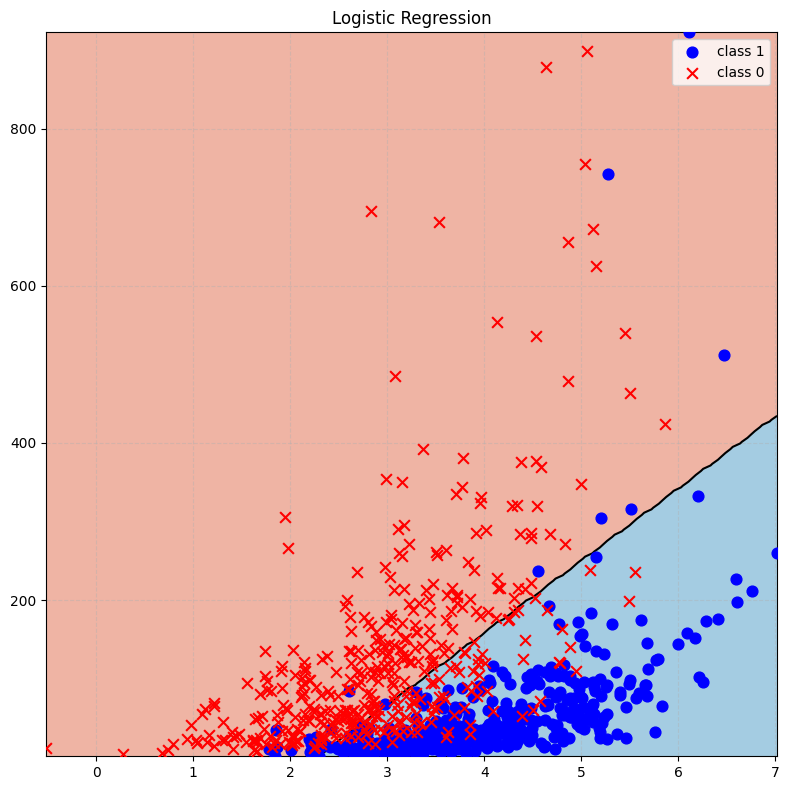

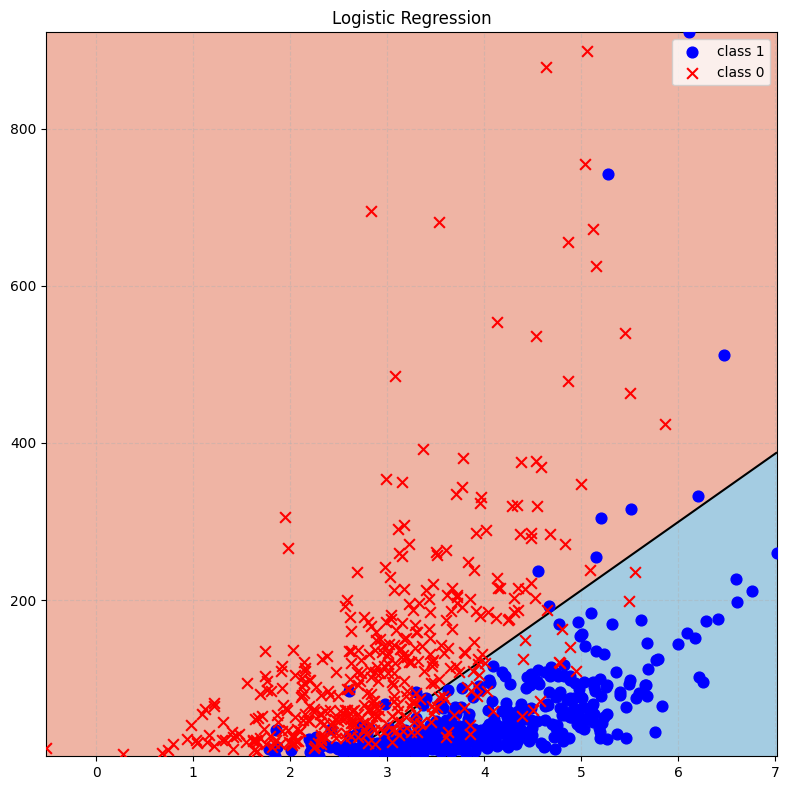

In [14]:
from models import LogisticRegression

log = LogisticRegression()
log.fit(X_train,y_train, method='gradient_descent', num_iterations=100000,learning_rate=0.1)
log.visualize(X_train,y_train,)
log.fit(X_train,y_train, method='gradient_descent', normalize=True, num_iterations=10000)
log.visualize(X_train,y_train, normalize=True)


<Axes: >

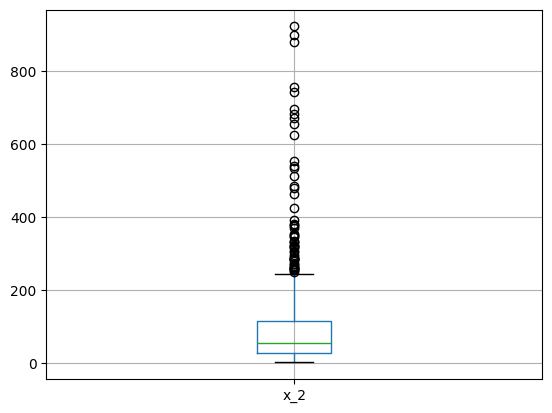

In [7]:
df_train[['x_2']].boxplot()

In [8]:
model = LogisticRegression()
model.fit(X_train, y_train)
visualize(model, X_train, y_train)
visualize(model,X_test,y_test)

AttributeError: 'LogisticRegression' object has no attribute 'predict_prob'